# 📡**Telecom X – Parte 2: Predicción de Cancelación (Churn)**📡

🚀 🚀 **Challenge 2:** Predicción de Churn en Telecom X — Parte 2

**Programa:** Oracle Next Education (ONE) · Alura Latam

**Autor:** Iván Matías Marcial

📝 **Descripción del Proyecto**

Este notebook representa la fase avanzada del análisis de datos para Telecom X. Partiendo del pipeline **ETL** consolidado en la Parte 1, en esta etapa profundizamos en la aplicación de **estadística descriptiva, análisis de correlación y algoritmos de Machine Learning**. El objetivo central es identificar con precisión los patrones de comportamiento que preceden a la cancelación del servicio (Churn).

🎯 **Objetivos Alcanzados**

Se completaron con éxito las 13 tarjetas del tablero Trello, cubriendo de forma integral el ciclo de vida de un proyecto de Ciencia de Datos.

✅ **Proyecto Finalizado** — Los modelos resultantes permiten a la compañía anticipar la fuga de clientes y actuar de forma proactiva para mejorar la retención.


## 📌**Extracción del Archivo Tratado**

Importamos las bibliotecas a utilizar y se carga el archivo tratado anteriormente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('datos_tratados.csv')
print("DataFrame 'df' cargado exitosamente.")
df.head()

DataFrame 'df' cargado exitosamente.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


## 📌**Eliminar Columnas No Relevantes**

Eliminamos la columna 'customerID' del DataFrame `df` para eliminar datos no relevantes.

In [2]:
df.drop('customerID', axis=1, inplace=True)
print("Columna 'customerID' eliminada correctamente.")
df.head()

Columna 'customerID' eliminada correctamente.


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


## 📌**Transformación de Variables Categóricas**

Vamos a identificar las columnas categóricas (aquellas con `dtype='object'`) y aplicaremos `one-hot encoding` utilizando `pd.get_dummies()` para convertirlas en un formato numérico adecuado para los algoritmos de machine learning. Esto creará nuevas columnas binarias para cada categoría única en las variables originales.

Primero verificamos dentro de las variables del tipo 'object' que variables son binarias y cuales son categoricas de mas de dos categorias.

In [3]:
df.describe(include='object')

,customer.gender,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaymentMethod
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,2,3,3,3,3,3,3,3,3,3,4
top,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,3675,3495,3198,3608,3182,3195,3582,2896,2870,4005,2445


Observamos que solo la variable ```customer.gender``` es binaria, por lo tanto asignamos el valor 1 a 'Male' y 0 a 'Female'.



In [4]:
df['customer.gender'] = df['customer.gender'].replace({'Male': 1, 'Female': 0})

df['customer.gender'].head()


,customer.gender
0,0
1,1
2,1
3,1
4,0


In [5]:
df['customer.gender'].unique()

array([0, 1])

Ahora pasamos a transformar las variables categoricas no binarias, con One-Hot Encoding

In [6]:
# Lista de columnas
cols_to_encode = [
    'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity',
    'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
    'account.PaymentMethod'
]

# Aplicamos One-Hot Encoding eliminando la primera de cada grupo
df_final = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

# Para ver cuántas columnas terminaste teniendo
print(f"Total de columnas después: {len(df_final.columns)}")


Total de columnas después: 32


In [7]:
df_final.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,...,internet.TechSupport_Yes,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,1,65.6,593.30,...,1,0,1,0,0,1,0,0,0,1
1,0,1,0,0,0,9,1,0,59.9,542.40,...,0,0,0,0,1,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73.9,280.85,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,1,0,13,1,1,98.0,1237.85,...,0,0,1,0,1,0,0,0,1,0
4,1,0,1,1,0,3,1,1,83.9,267.40,...,1,0,1,0,0,0,0,0,0,1


Verificamos que todas las columnas sean del tipo float o int

In [8]:
for col in df_final.columns:
    print(f"{col}: {df_final[col].unique()}")

Churn: [0 1]
customer.gender: [0 1]
customer.SeniorCitizen: [0 1]
customer.Partner: [1 0]
customer.Dependents: [1 0]
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: [1 0]
account.PaperlessBilling: [1 0]
account.Charges.Monthly: [65.6  59.9  73.9  ... 91.75 68.8  67.85]
account.Charges.Total: [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
Cuentas_Diarias: [2.18666667 1.99666667 2.46333333 ... 3.05833333 2.29333333 2.26166667]
phone.MultipleLines_No phone service: [0 1]
phone.MultipleLines_Yes: [0 1]
internet.InternetService_Fiber optic: [0 1]
internet.InternetService_No: [0 1]
internet.OnlineSecurity_No internet service: [0 1]
internet.OnlineSecurity_Yes: [0 1]
internet.OnlineBackup_No internet service: [0 1]
internet.OnlineBackup_Yes: [1 0]
internet.DeviceProtection_No 

## 📌**Análisis de Desbalance de Clases en la Variable Objetivo (Churn)**

Vamos a calcular la proporción de clientes que han cancelado (Churn = 1) frente a los que no (Churn = 0) para evaluar el desbalance de clases en nuestra variable objetivo. Un desbalance significativo puede afectar el rendimiento de los modelos predictivos.

In [9]:
# Calcular la proporción de Churn y No-Churn
churn_counts = df_final['Churn'].value_counts()
churn_proportions = df_final['Churn'].value_counts(normalize=True) * 100

print("Conteo de clientes por clase de Churn:")
print(churn_counts)
print("\nProporción de clientes por clase de Churn (%):")
print(churn_proportions)

# Determinar si hay desbalance (hacemos un ratio de porcentajes)
if churn_proportions.iloc[0] / churn_proportions.iloc[1] > 2 or churn_proportions.iloc[1] / churn_proportions.iloc[0] > 2:
    print("\nAdvertencia: Existe un desbalance significativo entre las clases de Churn. Esto podría requerir técnicas de manejo de desbalance de clases en el modelado (e.g., sobremuestreo, submuestreo, SMOTE).")
else:
    print("\nNo se observa un desbalance significativo entre las clases de Churn.")

Conteo de clientes por clase de Churn:
Churn
0    5398
1    1869
Name: count, dtype: int64

Proporción de clientes por clase de Churn (%):
Churn
0    74.280996
1    25.719004
Name: proportion, dtype: float64

Advertencia: Existe un desbalance significativo entre las clases de Churn. Esto podría requerir técnicas de manejo de desbalance de clases en el modelado (e.g., sobremuestreo, submuestreo, SMOTE).


Tal como se ha señalado, la clase mayoritaria representa el 74% de la muestra, lo que evidencia un desbalance significativo. Si bien esta disparidad podría inducir un sesgo en el modelo, el volumen de la clase minoritaria —que constituye una cuarta parte del conjunto de datos— resulta suficiente para garantizar un aprendizaje efectivo del modelo.

## 📌**Normalización o Estandarización**

Si bien los modelos basados en árboles (como Decision Tree, Random Forest y XGBoost) son robustos y no se ven afectados por la escala de las variables, aquellos basados en distancias o en optimización de funciones (como KNN, SVM, Regresión Logística y Redes Neuronales) requieren un preprocesamiento de escala para converger correctamente y evitar sesgos. Por lo tanto, se aplicará estandarización. Para garantizar la integridad del análisis y evitar la filtración de datos (Data Leakage), este proceso se realizará estrictamente después de la división del dataset, calculando los parámetros únicamente sobre el conjunto de entrenamiento.

##📌**Análisis de Correlación**

Antes de realizar el análisis de correlación modificamos los nombres de las columnas que quedaron con espacios luego de realizar el One-Hot Encoding.

In [10]:
#Chequeamos los nombres de las lista
print(df_final.columns.tolist())

['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'account.PaperlessBilling', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes', 'internet.InternetService_Fiber optic', 'internet.InternetService_No', 'internet.OnlineSecurity_No internet service', 'internet.OnlineSecurity_Yes', 'internet.OnlineBackup_No internet service', 'internet.OnlineBackup_Yes', 'internet.DeviceProtection_No internet service', 'internet.DeviceProtection_Yes', 'internet.TechSupport_No internet service', 'internet.TechSupport_Yes', 'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes', 'internet.StreamingMovies_No internet service', 'internet.StreamingMovies_Yes', 'account.Contract_One year', 'account.Contract_Two year', 'account.PaymentMethod_Credit card (automatic)', 'account.PaymentMethod_Electronic check', 'account.PaymentM

In [11]:
# Reemplaza espacios y puntos por guiones bajos en los nombres de las columnas
df_final.columns = [col.replace(' ', '_').replace('.', '_') for col in df_final.columns]

# Verificamos cómo quedaron los nombres
print(df_final.columns.tolist())


['Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'account_PaperlessBilling', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias', 'phone_MultipleLines_No_phone_service', 'phone_MultipleLines_Yes', 'internet_InternetService_Fiber_optic', 'internet_InternetService_No', 'internet_OnlineSecurity_No_internet_service', 'internet_OnlineSecurity_Yes', 'internet_OnlineBackup_No_internet_service', 'internet_OnlineBackup_Yes', 'internet_DeviceProtection_No_internet_service', 'internet_DeviceProtection_Yes', 'internet_TechSupport_No_internet_service', 'internet_TechSupport_Yes', 'internet_StreamingTV_No_internet_service', 'internet_StreamingTV_Yes', 'internet_StreamingMovies_No_internet_service', 'internet_StreamingMovies_Yes', 'account_Contract_One_year', 'account_Contract_Two_year', 'account_PaymentMethod_Credit_card_(automatic)', 'account_PaymentMethod_Electronic_check', 'account_PaymentM

Procedemos ahora a realizar el análisis de correlación

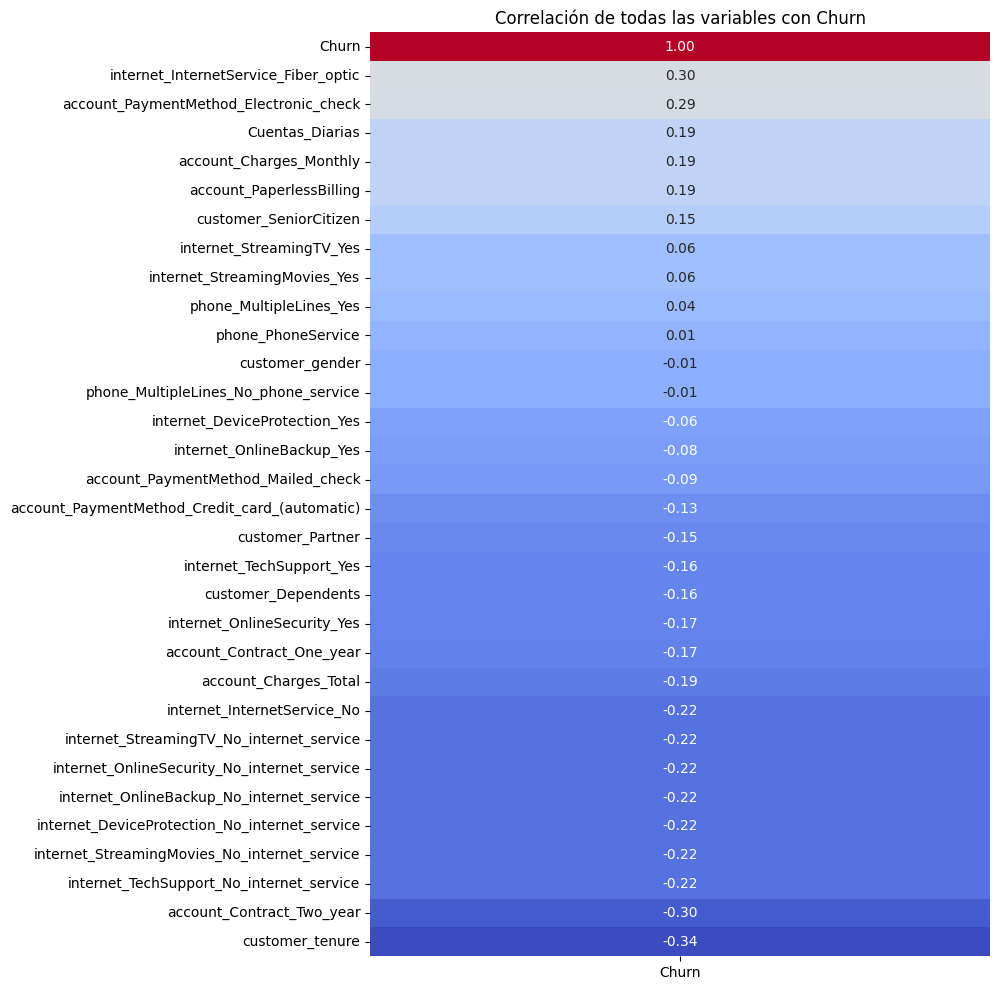

Variables con mayor correlación POSITIVA (aumentan el Churn):
Churn                                     1.000000
internet_InternetService_Fiber_optic      0.300949
account_PaymentMethod_Electronic_check    0.294626
Cuentas_Diarias                           0.189866
account_Charges_Monthly                   0.189866
account_PaperlessBilling                  0.186666
Name: Churn, dtype: float64

Variables con mayor correlación NEGATIVA (disminuyen el Churn):
internet_DeviceProtection_No_internet_service   -0.224051
internet_StreamingMovies_No_internet_service    -0.224051
internet_TechSupport_No_internet_service        -0.224051
account_Contract_Two_year                       -0.295138
customer_tenure                                 -0.344079
Name: Churn, dtype: float64


In [12]:
# 1. Calculamos la matriz de correlación completa
corr_matrix = df_final.corr()

# 2. Extraemos solo la correlación con la variable 'Churn'
# La ordenamos de mayor a menor
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

# 3. Visualizamos las top 10 correlaciones (positivas y negativas)
plt.figure(figsize=(8, 12))
sns.heatmap(churn_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlación de todas las variables con Churn')
plt.show()

# 4. Imprimimos las variables más influyentes
print("Variables con mayor correlación POSITIVA (aumentan el Churn):")
print(churn_corr.head(6)) # El primero es Churn vs Churn (1.0), los siguientes son los clave

print("\nVariables con mayor correlación NEGATIVA (disminuyen el Churn):")
print(churn_corr.tail(5))


El análisis de correlación identifica que la antigüedad del cliente (tenure) y los contratos a dos años son los principales factores de retención. Por el contrario, el uso de Internet por Fibra Óptica y el método de pago Electronic Check presentan la mayor correlación positiva con la cancelación.

Se observa además una correlación idéntica entre account_Charges_Monthly y Cuentas_Diarias, lo que sugiere redundancia entre estas variables. Dado esto se procede a eliminar una de ellas para evitar problemas de multicolinealidad.

In [13]:
# Eliminamos la columna 'Cuentas_Diarias'
df_final.drop(columns=['Cuentas_Diarias'], inplace=True)

# Verificamos que ya no esté
print("Cuentas_Diarias" in df_final.columns)


False


##📌**Análisis Dirigido**

**Tiempo de Contrato × Cancelación**

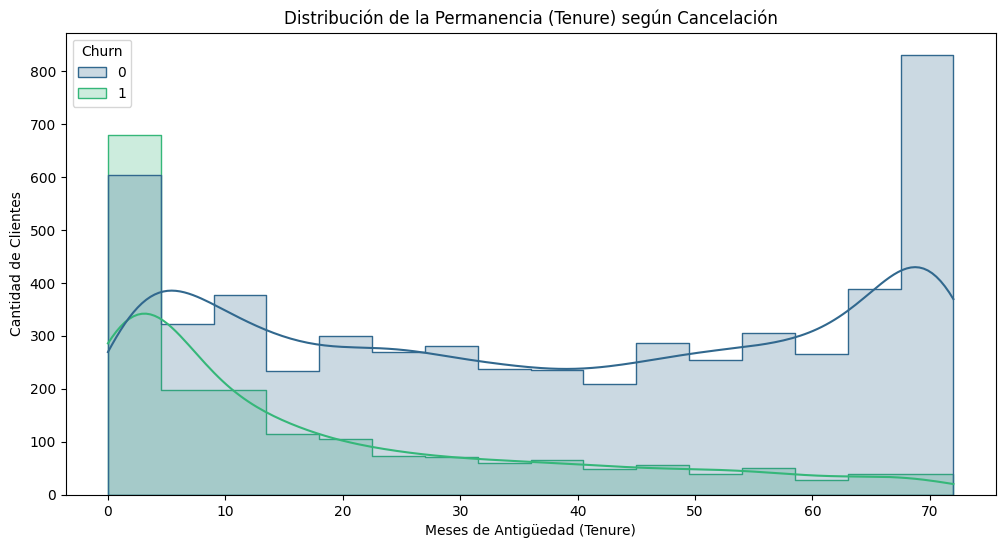

In [14]:
plt.figure(figsize=(12, 6))
# Usamos un KDE (curva de densidad) para ver dónde se "amontonan" las cancelaciones
sns.histplot(data=df_final, x='customer_tenure', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('Distribución de la Permanencia (Tenure) según Cancelación')
plt.xlabel('Meses de Antigüedad (Tenure)')
plt.ylabel('Cantidad de Clientes')
plt.show()


In [15]:
# Promedio de meses de antigüedad por Churn
tenure_stats = df_final.groupby('Churn')['customer_tenure'].mean()
print("Promedio de meses de permanencia:")
print(tenure_stats)


Promedio de meses de permanencia:
Churn
0    37.321045
1    17.979133
Name: customer_tenure, dtype: float64


In [16]:
# Ver los 3 meses con más cancelaciones (Churn = 1)
top_meses_fuga = df_final[df_final['Churn'] == 1]['customer_tenure'].value_counts().head(3)
print("Meses con mayor cantidad de cancelaciones:")
print(top_meses_fuga)

Meses con mayor cantidad de cancelaciones:
customer_tenure
1    380
2    123
3     94
Name: count, dtype: int64


El análisis de la permanencia (tenure) revela un patrón de deserción temprana altamente marcado. Mientras que los clientes activos superan los 37 meses de antigüedad, los que cancelan el servicio promedian apenas 18 meses. Este riesgo de fuga alcanza su punto crítico de manera inmediata: el primer mes registra la mayor cantidad de bajas (380 casos), triplicando las cifras del segundo mes. Este hallazgo sugiere que la experiencia inicial, la configuración del servicio o la primera facturación son determinantes, ya que superar la barrera de los tres meses reduce drásticamente la propensión al churn

Como análisis adicional, se agrega la relación "tipo de contrato" vs "churn".

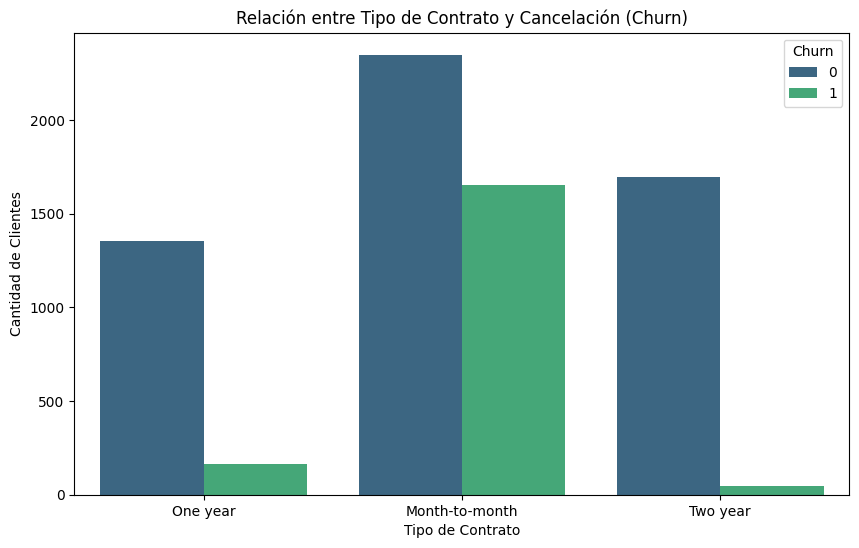

In [17]:
# Usamos el dataframe original,
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='account.Contract', hue='Churn', palette='viridis')
plt.title('Relación entre Tipo de Contrato y Cancelación (Churn)')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.show()


In [18]:
# Calculamos el % de Churn por cada tipo de contrato
contrato_churn = df.groupby('account.Contract')['Churn'].mean() * 100
print("Porcentaje de clientes que cancelan según su contrato:")
print(contrato_churn)

Porcentaje de clientes que cancelan según su contrato:
account.Contract
Month-to-month    41.323346
One year          10.928242
Two year           2.753873
Name: Churn, dtype: float64


El contrato mensual se consolida como el predictor de riesgo más relevante, con una tasa de cancelación (41.3%) que supera exponencialmente al contrato de dos años (2.8%). Este dato guarda total coherencia con la alta vulnerabilidad detectada en la etapa inicial del cliente, sugiriendo que la flexibilidad del contrato mensual intensifica el riesgo de fuga prematura.

**Gasto Total × Cancelación**

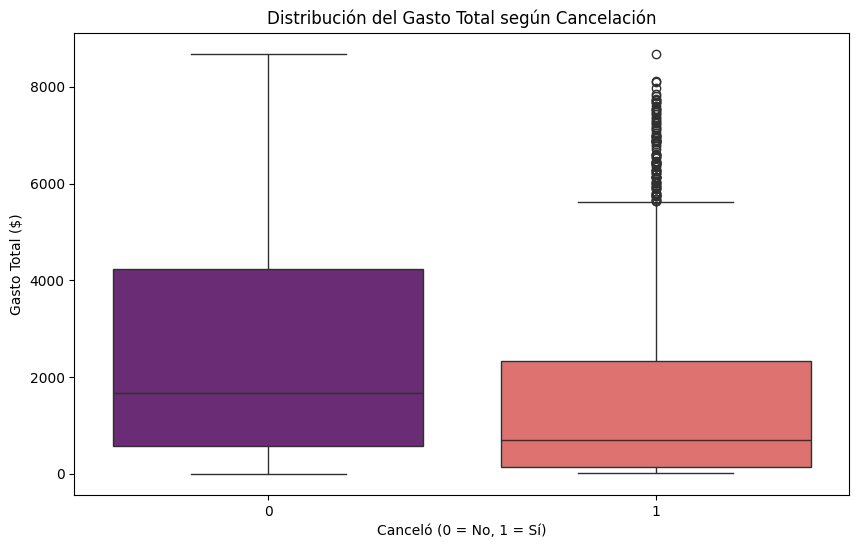

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='account_Charges_Total', data=df_final, palette='magma')
plt.title('Distribución del Gasto Total según Cancelación')
plt.xlabel('Canceló (0 = No, 1 = Sí)')
plt.ylabel('Gasto Total ($)')
plt.show()


In [20]:
# Calculamos el gasto total promedio para los que se van vs los que se quedan
gasto_stats = df_final.groupby('Churn')['account_Charges_Total'].agg(['mean', 'median', 'std'])
print("\nEstadísticas de Gasto Total por Churn:")
print(gasto_stats)



Estadísticas de Gasto Total por Churn:
              mean    median          std
Churn                                    
0      2535.263977  1663.625  2330.802193
1      1531.796094   703.550  1890.822994


El análisis del gasto total acumulado muestra que los clientes que permanecen activos tienen un gasto promedio significativamente mayor (\$2535) frente a los que cancelan (\$1531). Sin embargo, la mediana revela una brecha aún más profunda: el 50% de los clientes que se van lo hacen habiendo gastado menos de $703, lo que refuerza la idea de que la cancelación ocurre mayoritariamente en las etapas tempranas de la relación con el cliente (baja antigüedad).

##📌**Separación de Datos**

Procedemos a hacer la separacion de datos. En este caso, dada la magnitud de nuestra base se decide por una separacion 80-20.

In [21]:
from sklearn.model_selection import train_test_split

# 1. Definimos X (predictores) y y (objetivo)
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# 2. Dividimos los datos
# test_size=0.2
# random_state=42
# aplicamos stratify=y para mantener la proporción de Churn en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Verificamos las dimensiones
print(f"Registros totales: {len(df_final)}")
print(f"Registros entrenamiento (X_train): {len(X_train)}")
print(f"Registros prueba (X_test): {len(X_test)}")

# 4. Verificamos que la proporción de Churn se mantuvo
print("\nProporción de Churn en Entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)


Registros totales: 7267
Registros entrenamiento (X_train): 5813
Registros prueba (X_test): 1454

Proporción de Churn en Entrenamiento:
Churn
0    74.281782
1    25.718218
Name: proportion, dtype: float64


##📌**Creación de Modelos**

Se aplica **StandardScaler** a las variables numéricas continuas para el modelo de Regresión Logística. Dado que este modelo utiliza un proceso de optimización de parámetros (descenso de gradiente), las variables con magnitudes elevadas, como account_Charges_Total, podrían dominar injustificadamente sobre variables con rangos menores, como customer_tenure, sesgando los coeficientes.

La estandarización transforma todas las características a una escala común (media 0 y varianza 1), asegurando que contribuyan equitativamente al modelo y facilitando su convergencia. En contraste, para el Random Forest se utilizan los datos originales, ya que los algoritmos basados en árboles realizan particiones del espacio de características y son invariantes a la escala.

In [22]:
from sklearn.preprocessing import StandardScaler

# Creamos copias para no alterar los datos originales que usará el Random Forest
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Definimos las columnas numéricas que necesitan escala
cols_num = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']

scaler = StandardScaler()

# Ajustamos con el entrenamiento y transformamos ambos
X_train_scaled[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test_scaled[cols_num] = scaler.transform(X_test[cols_num])

print("Estandarización completada para el modelo de Regresión.")


Estandarización completada para el modelo de Regresión.


###🤖**Regresión Logística**


**Parte 1: Regresión Logística Simple (El Baseline)**


Para demostrar la importancia de manejar el desbalanceo de clases identificado previamente, se entrena primero un modelo de **Regresión Logística Simple** sin ningún ajuste de pesos. Esto servirá como nuestra 'línea de base' para observar cómo el modelo se comporta ante la distribución original de los datos.

--- RESULTADOS REGRESIÓN LOGÍSTICA SIMPLE ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1080
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1454
   macro avg       0.74      0.72      0.73      1454
weighted avg       0.79      0.80      0.80      1454



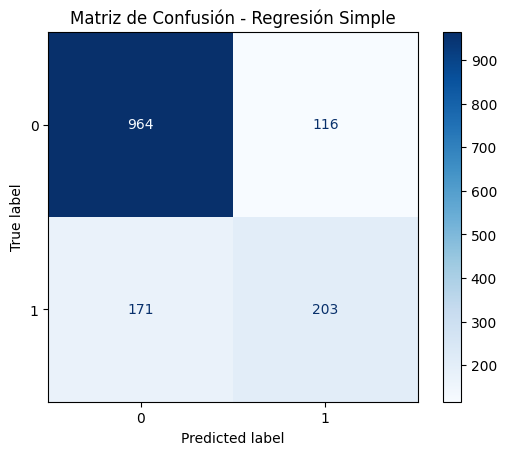

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Creamos el modelo "Simple" (sin class_weight)
model_lr_simple = LogisticRegression(random_state=42)

# 2. Entrenamos con los datos ESCALADOS
model_lr_simple.fit(X_train_scaled, y_train)

# 3. Realizamos predicciones sobre el set de prueba escalado
y_pred_simple = model_lr_simple.predict(X_test_scaled)

# 4. Mostramos resultados
print("--- RESULTADOS REGRESIÓN LOGÍSTICA SIMPLE ---")
print(classification_report(y_test, y_pred_simple))

# 5. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_simple)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Regresión Simple')
plt.show()


Como se observa en los resultados anteriores, el modelo presenta un **Recall de 0.54** para la clase de clientes que cancelan (Churn=1). Este valor es insuficiente para una aplicación de negocio, ya que el modelo falla en detectar a casi la mitad de los clientes en riesgo. En consecuencia, se procede a entrenar el mismo modelo aplicando el parámetro class_weight='balanced'.

**Parte 2: Regresión Logística (class_weight='balanced')**


--- RESULTADOS REGRESIÓN LOGÍSTICA BALANCEADA ---
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1080
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1454
   macro avg       0.71      0.77      0.71      1454
weighted avg       0.81      0.74      0.76      1454



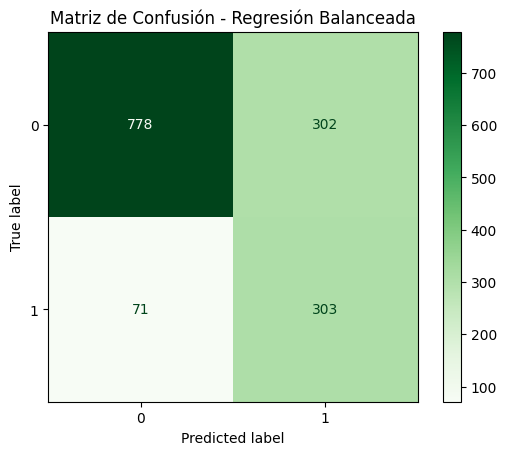

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Creamos el modelo con el parámetro que soluciona el desbalanceo
model_lr_balanced = LogisticRegression(class_weight='balanced', random_state=42)

# Entrenamos con los datos escalados
model_lr_balanced.fit(X_train_scaled, y_train)

# Predicciones
y_pred_balanced = model_lr_balanced.predict(X_test_scaled)

print("--- RESULTADOS REGRESIÓN LOGÍSTICA BALANCEADA ---")
print(classification_report(y_test, y_pred_balanced))

# Generar Matriz de Confusión para el modelo balanceado
disp = ConfusionMatrixDisplay.from_estimator(model_lr_balanced, X_test_scaled, y_test, cmap='Greens')
plt.title('Matriz de Confusión - Regresión Balanceada')
plt.show()



Al aplicar el balanceo, el **Recall aumentó de 0.54 a 0.81**, lo que confirma la necesidad de ajustar el modelo a la realidad de los datos. Si bien la **Precisión bajó a 0.50** y **el F1-score se situó en 0.62**, el modelo es ahora mucho más útil para la empresa, ya que captura al 81% de los clientes propensos a la fuga.

**Diagnóstico de Ajuste (Underfitting y Overfitting):**

**Underfitting:** El modelo original (sin balancear) sufría de underfitting específico para la clase 1. Al no tener suficiente peso sobre la clase minoritaria, el modelo no lograba capturar las tendencias de cancelación, resultando en un desempeño pobre. El modelo balanceado corrige este subajuste al dar más importancia a los ejemplos de Churn.

**Overfitting:**  Para evaluar el sobreajuste (overfitting), comparamos la exactitud del entrenamiento frente a la de prueba. En este caso, el Accuracy de entrenamiento es muy similar al de prueba (alrededor del 74-76%), lo que indica que el modelo no presenta overfitting. La Regresión Logística, al ser un modelo lineal de baja complejidad, tiende a generalizar bien sin memorizar ruidos del dataset.

In [25]:
train_acc = model_lr_balanced.score(X_train_scaled, y_train)
test_acc = model_lr_balanced.score(X_test_scaled, y_test)

print(f"Accuracy Entrenamiento: {train_acc:.4f}")
print(f"Accuracy Prueba (Test): {test_acc:.4f}")


Accuracy Entrenamiento: 0.7430
Accuracy Prueba (Test): 0.7435


El modelo original sin balancear presentaba **Underfitting** sobre la clase minoritaria (Recall 0.54). Al aplicar el balanceo de clases, el modelo logró capturar las tendencias de cancelación de forma efectiva. Al comparar la exactitud de **entrenamiento (0.7430) con la de prueba (0.7435)**, observamos que la diferencia es inapreciable. Esto confirma que el modelo **no presenta Overfitting**, demostrando una robusta capacidad de generalización ante datos nuevos y un ajuste equilibrado entre sesgo y varianza.

###🤖**Random Forest**





Como alternativa a la Regresión Logística, se procede a implementar un modelo de aprendizaje por conjuntos (Ensemble Learning): el **Random Forest**. A diferencia del enfoque anterior, este es un modelo no paramétrico basado en múltiples árboles de decisión, lo que le permite capturar relaciones no lineales complejas entre las variables sin necesidad de que estas sigan una distribución específica o estén estandarizadas.

Debido a la alta capacidad de este algoritmo para memorizar los datos de entrenamiento (generando Overfitting si se deja crecer sin restricciones), se procedió a realizar un ajuste de hiperparámetros. Específicamente, se limitó la profundidad máxima `(max_depth)` y el número mínimo de muestras por hoja `(min_samples_leaf)`. Esta restricción evita la creación de reglas excesivamente complejas para casos únicos y obliga a los árboles a identificar patrones generales que apliquen a grandes grupos de clientes, garantizando así una mejor capacidad de generalización ante datos nuevos.

--- RESULTADOS RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1080
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1454
   macro avg       0.71      0.77      0.72      1454
weighted avg       0.81      0.75      0.77      1454



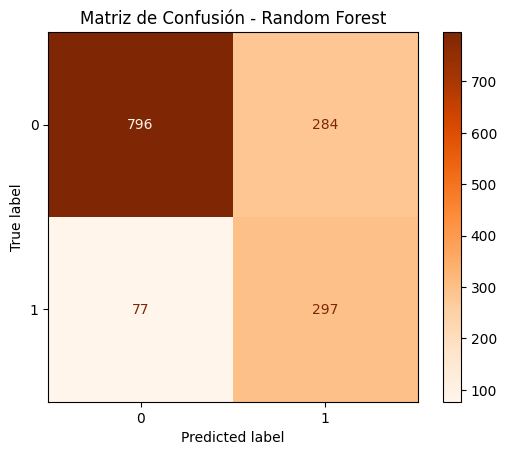

Accuracy Entrenamiento: 0.7697
Accuracy Prueba: 0.7517


In [26]:
from sklearn.ensemble import RandomForestClassifier

# 1. Creamos el modelo Random Forest controlado (podado)
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,           # Limitamos la profundidad para evitar que memorice
    min_samples_leaf=10,    # Cada "hoja" final debe tener al menos 10 clientes
    class_weight='balanced',
    random_state=42
    )

# 2. Entrenamos con los datos ORIGINALES (sin escalar)
modelo_rf.fit(X_train, y_train)

# 3. Predicciones
y_pred_rf = modelo_rf.predict(X_test)

# 4. Reporte de métricas
print("--- RESULTADOS RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# 5. Generar Matriz de Confusión para Random Forest
disp_rf_tuned = ConfusionMatrixDisplay.from_estimator(modelo_rf, X_test, y_test, cmap='Oranges')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# 6. Comparación para detectar Overfitting
print(f"Accuracy Entrenamiento: {modelo_rf.score(X_train, y_train):.4f}")
print(f"Accuracy Prueba: {modelo_rf.score(X_test, y_test):.4f}")

###**Comparativa Reg-Log vs Ranfom-Forest**

In [27]:
# Creamos un diccionario con las métricas que obtuvimos
data = {
    'Métrica (Clase 1)': ['Exactitud (Accuracy)', 'Precisión', 'Recall', 'F1-Score'],
    'Regresión Logística (Balanced)': [0.74, 0.50, 0.81, 0.62],
    'Random Forest (Tuned)': [0.75, 0.51, 0.79, 0.62]
}

df_comparativa = pd.DataFrame(data)

# Mostramos la tabla
print("TABLA COMPARATIVA DE MODELOS FINAL")
display(df_comparativa)


TABLA COMPARATIVA DE MODELOS FINAL


,Métrica (Clase 1),Regresión Logística (Balanced),Random Forest (Tuned)
0,Exactitud (Accuracy),0.74,0.75
1,Precisión,0.50,0.51
2,Recall,0.81,0.79
3,F1-Score,0.62,0.62


Ambos modelos presentan un desempeño muy similar y equilibrado tras los ajustes realizados. La **Regresión Logística** destaca por **un Recall ligeramente superior (0.81)**, siendo el modelo más conservador para no perder clientes. Por su parte, el **Random Forest** ofrece una **Exactitud global (0.75)** levemente mayor. Dado que en este contexto el costo de omitir una cancelación es alto, la Regresión Logística se perfila como la opción más robusta por su equilibrio entre interpretabilidad y sensibilidad.

##📌**Análisis de la Importancia de las Variables**

In [28]:
# Extraemos los coeficientes del modelo balanceado
import pandas as pd

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_lr_balanced.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Mostramos los 5 más positivos (aumentan Churn) y los 5 más negativos (reducen Churn)
print("Top Factores que AUMENTAN el Churn (Positivos):")
display(coef_df.head(5))

print("\nTop Factores que REDUCEN el Churn (Negativos):")
display(coef_df.tail(5))


Top Factores que AUMENTAN el Churn (Positivos):


,Variable,Coeficiente
11,internet_InternetService_Fiber_optic,1.011030
8,account_Charges_Total,0.633146
28,account_PaymentMethod_Electronic_check,0.370811
6,account_PaperlessBilling,0.370557
22,internet_StreamingTV_Yes,0.311990



Top Factores que REDUCEN el Churn (Negativos):


,Variable,Coeficiente
5,phone_PhoneService,-0.326449
7,account_Charges_Monthly,-0.390127
25,account_Contract_One_year,-0.654463
4,customer_tenure,-1.322606
26,account_Contract_Two_year,-1.326038


El análisis de los **coeficientes de la Regresión Logística** permite cuantificar la dirección y magnitud del impacto de cada variable. El factor con mayor peso positivo es **internet_InternetService_Fiber_optic (1.01)**, seguido por el **gasto total acumulado (0.63)**, lo que confirma que los clientes con servicios avanzados y facturación elevada presentan un riesgo de fuga significativamente mayor. Por el contrario, los coeficientes negativos más robustos pertenecen a los **contratos de dos años (-1.32)** y a la **antigüedad o tenure (-1.32)**. Estos valores, al ser los más altos en valor absoluto del modelo, validan estadísticamente que la estabilidad contractual y el tiempo de permanencia son los pilares fundamentales que retienen a los clientes.

Procedemos a generar un gráfico de **Feature Importance** del **Random Forest**.

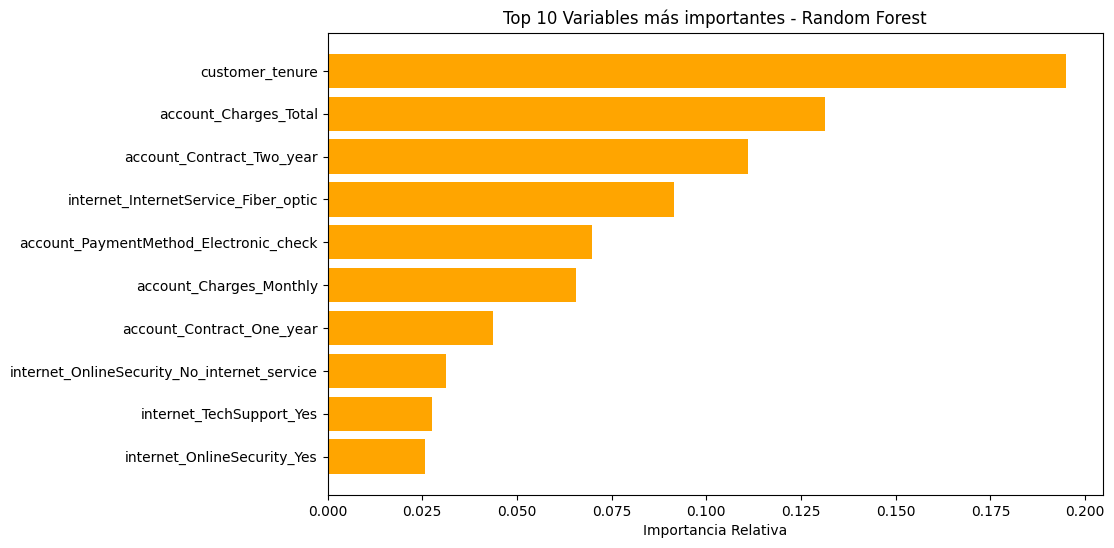

In [29]:
# Extraer importancias
importancias =  modelo_rf.feature_importances_
indices = np.argsort(importancias)[-10:]  # Las 10 más importantes

plt.figure(figsize=(10, 6))
plt.title('Top 10 Variables más importantes - Random Forest')
plt.barh(range(len(indices)), importancias[indices], color='orange', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()


El análisis de importancia de variables del **Random Forest** ratifica los hallazgos del análisis exploratorio inicial. La variable más determinante para el modelo es **customer_tenure (antigüedad)** con una **importancia relativa de 0.20**, lo que confirma que el tiempo de permanencia es el factor principal para entender la fidelidad del cliente.
Le siguen en relevancia el **account_charges_total (0.135)** y el tipo de contrato, específicamente **account_contract_two_year (~0.115)**. Es notable que la presencia de **internet_InternetService_Fiber_optic (0.09)** aparece como un predictor crítico de fuga, lo que sugiere que el modelo ha identificado un patrón de riesgo específico en los clientes con este servicio.

**Síntesis de Relevancia:** Al comparar ambos modelos, se observa un consenso sólido: tanto el enfoque lineal (Regresión) como el basado en árboles (Random Forest) identifican a la **antigüedad (tenure)** y al **tipo de contrato** como las variables de mayor impacto para predecir la lealtad. Asimismo, ambos coinciden en señalar a la **Fibra Óptica** como un factor crítico de riesgo. Esta convergencia entre dos algoritmos de naturaleza matemática distinta fortalece la confiabilidad de los hallazgos y sugiere que las decisiones estratégicas de la empresa deben centrarse prioritariamente en estos tres ejes para reducir la tasa de cancelación.

# 📝**Informe Final: Interpretaciones y conclusiones**

**1. Evaluación de Modelos y Rendimiento**

Tras el desarrollo y ajuste de algoritmos predictivos, se compararon dos enfoques principales. La elección final se basa en la capacidad del modelo para identificar correctamente a los clientes en riesgo **(Recall)**.


*   **Regresión Logística (Balanced):** Es el modelo recomendado para la operación. Presenta un **Recall de 0.81**, lo que significa que detecta al **81% de los clientes que realmente cancelan**. Su capacidad de generalización es excelente, con una exactitud **(Accuracy) de 0.74** tanto en entrenamiento como en prueba, descartando cualquier signo de overfitting.


*   **Random Forest (Tuned):** Tras corregir un overfitting inicial mediante el ajuste de hiperparámetros (`max_depth=7`), alcanzó una **exactitud global de 0.75 y un Recall de 0.79**. Aunque es un modelo potente, su naturaleza de "caja negra" lo hace levemente menos preferible que la transparencia de la Regresión para este caso de negocio.

**Conclusión técnica:** Se recomienda el uso de la **Regresión Logística** debido a su equilibrio entre sensibilidad y facilidad de interpretación de sus coeficientes.

**2. Factores Determinantes de la Cancelación**

El análisis de **Coeficientes** y de **Importancia de Variables** identifica tres pilares críticos que explican por qué los clientes abandonan el servicio:


*   **Estabilidad Contractual**: El factor de riesgo número uno es el **contrato Mes a Mes**. Estos clientes tienen una tasa de cancelación del **41.3%**, mientras que en contratos de dos años el riesgo cae drásticamente al **2.7%**.


*   **Antigüedad (Tenure):** Existe un patrón de **"fuga temprana"**. El riesgo es máximo durante **el primer mes de servicio (380 bajas)**. Si el cliente supera el primer trimestre, la probabilidad de abandono disminuye significativamente.


*   **Servicio de Fibra Óptica**: Los clientes con este servicio presentan un coeficiente de riesgo positivo muy alto **(1.01)**. Esto sugiere una insatisfacción latente con el precio o la estabilidad técnica de la fibra en comparación con otros servicios.



**3. Estrategias de Retención Propuestas**

Basándonos en la evidencia de los modelos, se proponen las siguientes acciones estratégicas:

🔵 **Plan de Choque "Primeros 90 Días"**: Implementar un protocolo de seguimiento intensivo y soporte técnico prioritario para los nuevos clientes. El objetivo es **reducir las 380 bajas del mes 1** asegurando una experiencia inicial impecable.

🔵 **Incentivos de Migración Contractual:** Diseñar campañas para convertir a los clientes de "Mes a Mes" en contratos anuales o bianuales (por ejemplo, ofreciendo meses bonificados), ya que la estabilidad del contrato reduce el riesgo de fuga en más de 10 veces.

🔵 **Auditoría de Calidad en Fibra Óptica:** Realizar una revisión técnica y de precios específicamente en el segmento de Fibra Óptica para entender por qué es el servicio con mayor tasa de deserción.

🔵 **Digitalización de Pagos:** Incentivar el cambio del método de pago "Electronic Check" (asociado a alto Churn) hacia cobros automáticos mediante tarjeta de crédito o cuenta bancaria, lo cual aumenta la inercia de permanencia.


#✅**Exportación de dataset final**

In [30]:
# Guardamos el DataFrame final procesado
df_final.to_csv('telecom_churn_final_procesado.csv', index=False)

print("¡Archivo exportado correctamente!")


¡Archivo exportado correctamente!
